# Galactic Data Challange

## 1. Spectral fiting of Cyg-X1

1.1 The first step is adding the libraries.

In [41]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

import sys

import astropy.units as u

import numpy as np
import matplotlib.pyplot as plt

from threeML import Band, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw

from pathlib import Path

%matplotlib inline

1.2 Then we make a folder for data.


In [42]:
data_path = Path("../cosi_galactic_constrain_geo_data/data")
data_path.mkdir(parents=True, exist_ok=True)


1.3 We download and load the orientation file.

In [43]:
ori_path = data_path/"DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori"
fetch_wasabi_file("COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori", ori_path)
sc_orientation = SpacecraftHistory.open(ori_path)

A file named ../cosi_galactic_constrain_geo_data/data/DC4_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori with the same ETag (ea0bf1fced99f3527579613debf4eaef-12) as the requested file already exists. Skipping.


1.4 We download the unbinned Cyg X1 data.

In [44]:

signal_path = data_path/"cygX1_hard_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
fetch_wasabi_file("COSI-SMEX/DC3/Data/Sources/cygX1_hard_3months_unbinned_data_filtered_with_SAAcut.fits.gz", signal_path)

A file named ../cosi_galactic_constrain_geo_data/data/cygX1_hard_3months_unbinned_data_filtered_with_SAAcut.fits.gz with the same ETag (fdd821a2cec15579976fcaed7b2c85bc-2) as the requested file already exists. Skipping.


1.5 We download the unbinned DC4 bakground.

In [45]:
background_path = data_path/"Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz"
fetch_wasabi_file("COSI-SMEX/DC4/Data/Backgrounds/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz", background_path)


A file named ../cosi_galactic_constrain_geo_data/data/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz with the same ETag (1c67e7a1517ef1b6042696f925296e22-3046) as the requested file already exists. Skipping.


1.6 We download the response files.

In [46]:
img_response_path = data_path/"ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
fetch_wasabi_file("COSI-SMEX/DC4/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5", img_response_path)

A file named ../cosi_galactic_constrain_geo_data/data/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5 with the same ETag (a976a4c109df71db3333a464000d7241-5) as the requested file already exists. Skipping.


We look at the response.

In [47]:
from cosipy.response import FullDetectorResponse

with FullDetectorResponse.open(img_response_path) as response:

    print(repr(response))

dr = FullDetectorResponse.open(img_response_path)

FILENAME: '/Users/mabapple2025/Projects/NASA/COSI/cosi_galactic_constrain_geo_data/data/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 768
    NSIDE: 8
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 10
    EDGES: [100.0 keV, 158.489 keV, 251.189 keV, 398.107 keV, 630.957 keV, 1000.0 keV, 1584.89 keV, 2511.89 keV, 3981.07 keV, 6309.57 keV, 10000.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 30
    EDGES: [0.0 deg, 6.0 deg, 12.0 deg, 18.0 deg, 24.0 d

1.7 We make the binned object from  cygX1 and bkg.

In [48]:
from cosipy import BinnedData

cygX1 = BinnedData(data_path/"cygX1.yaml")
cygX1.get_binned_data(unbinned_data=signal_path, output_name=data_path/"cygX1_binned_data")

bkg = BinnedData(data_path/"background.yaml")
bkg.get_binned_data(unbinned_data=background_path, output_name=data_path/"bkg_binned_data")


1.8 We project the binned data to 'Em', 'Phi', and 'PsiChi'.

In [49]:
from histpy import Histogram

cygX1_binned_signal = Histogram.open(data_path/"cygX1_binned_data.hdf5")
cygX1_binned_signal_projected = cygX1_binned_signal.project(['Em', 'Phi', 'PsiChi'])

bkg_binned_signal = Histogram.open(data_path/"bkg_binned_data.hdf5")
bkg_binned_signal_projected = bkg_binned_signal.project(['Em', 'Phi', 'PsiChi'])

1.9 We perform the spectral fit by setting background parameters, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin.

In [50]:
# Wrap the raw BinnedData objects into the appropiate data interface.
data = EmCDSBinnedData(cygX1_binned_signal_projected + bkg_binned_signal_projected)  # total counts (source + background)

# Use the background model to initialize a background expectation interface.
# For this particular background interface implementation, only the normalization values are free.
bkg_dist = {"total_bkg":bkg_binned_signal_projected}
bkg = FreeNormBinnedBackground(bkg_dist, 
                               sc_history=sc_orientation, 
                               copy = False)

# Wrape the raw response with BinnedInstrumentResponseInterface implementation
instrument_response = BinnedInstrumentResponse(dr, data)

# Initialize the 3ML Point Source response

# Note: Currently we're using the same NuLambda, Ei and Pol axes as the underlying FullDetectorResponse,
# matching the behavior of v0.3. This is all the current BinnedInstrumentResponse can do.
# In principle, this can be decoupled, and a BinnedInstrumentResponseInterface implementation
# can provide the response for an arbitrary directions, Ei and Pol values.
psr = BinnedThreeMLPointSourceResponse(data = data,
                                       instrument_response = instrument_response,
                                       sc_history=sc_orientation,
                                       energy_axis = dr.axes['Ei'],
                                       polarization_axis = dr.axes['Pol'] if 'Pol' in dr.axes.labels else None,
                                       nside = 2*data.axes['PsiChi'].nside)

# Pass the 3ML Point Source response to interface implementation that will peform the 
# folding with the spectrum
response = BinnedThreeMLModelFolding(data = data, 
                                     point_source_response = psr)

# Likelihood to use
like_fun = PoissonLikelihood(data, response, bkg)

# Init 3ML plugin
cosi = ThreeMLPluginInterface('cosi',
                              like_fun,
                              response,
                              bkg)

# Init background parameters, consider as "nuisance parameters"
for bkg_label in bkg_dist.keys():
    cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,  # background parameter
                                      1,  # initial value of parameter
                                      min_value=0,  # minimum value of parameter
                                      max_value= 100,  # maximum value of parameter
                                      delta=0.05,  # initial step used by fitting engine
                                      unit = u.Hz
                                      )

1.10 Define a point source at the known location with a Band function spectrum and add it to the model. 

In [51]:
l = 71.3
b = 3.1

alpha = -1.99
beta = -2.32
E0 = 531. * (alpha - beta) * u.keV
xp = E0 * (alpha + 2) / (alpha - beta)
piv = 500. * u.keV
K = 3.07e-5 / u.cm / u.cm / u.s / u.keV

spectrum = Band()

spectrum.alpha.min_value = -2.14
spectrum.alpha.max_value = 3.0
spectrum.beta.min_value = -5.0
spectrum.beta.max_value = -2.15
spectrum.xp.min_value = 1.0
spectrum.alpha.delta = 0.01
spectrum.beta.delta = 0.01

spectrum.alpha.value = alpha
spectrum.beta.value = beta
spectrum.xp.value = xp.value
spectrum.K.value = K.value
spectrum.piv.value = piv.value

spectrum.xp.unit = xp.unit
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

source = PointSource("source",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

# Optional: free the position parameters
#source.position.l.free = True
#source.position.b.free = True

model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)


17:12:36 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=7470349;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=7470350;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

1.11 Gather all plugins and combine with the model in a JointLikelihood object, then perform maximum likelihood fit.

In [52]:
#[magic commented out by run_tutorials.py]%%time

plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)

like = JointLikelihood(model, plugins, verbose = False)

_ = like.fit()

17:12:36 INFO      set the minimizer to minuit                                             ]8;id=7470355;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=7470356;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


WARNING RuntimeWarning: divide by zero encountered in log


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: divide by zero encountered in log


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: divide by zero encountered in log


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: divide by zero encountered in log


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: divide by zero encountered in log


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: invalid value encountered in multiply


WARNING RuntimeWarning: divide by zero encountered in log



17:12:50 WARNING   48.18 percent of samples have been thrown away because they failed the  ]8;id=7470361;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=7470362;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

17:12:50 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=7470367;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=7470368;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

Best fit values:

...

1.00,-0.70,-0.84,0.46,0.02
-0.70,1.00,0.97,-0.36,-0.13
-0.84,0.97,1.00,-0.44,-0.15
0.46,-0.36,-0.44,1.00,-0.22
0.02,-0.13,-0.15,-0.22,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-1087366148.028134
total,-1087366148.028134


Values of statistical measures:

,statistical measures
AIC,-2174732286.056008
BIC,-2174732234.318407


1.12 The summary of the results above tell you the optimal values of the parameters, as well as the errors. Propogate the errors to the "evaluate_at" method of the spectrum.

In [53]:
results = like.results

print(results.display())

parameters = {par.name:results.get_variates(par.path)
              for par in results.optimized_model["source"].parameters.values()
              if par.free}

results_err = results.propagate(results.optimized_model["source"].spectrum.main.shape.evaluate_at, **parameters)

print(results.optimized_model["source"])

Best fit values:

,result,unit
parameter,,
source.spectrum.main.Band.K,(3.50 +/- 0.05) x 10^-5,1 / (keV s cm2)
source.spectrum.main.Band.alpha,-1.99696 +/- 0.00014,
source.spectrum.main.Band.xp,1.00 +/- 0.06,keV
source.spectrum.main.Band.beta,-3.007 +/- 0.027,
total_bkg,(2.56249 +/- 0.00026) x 10,Hz


Correlation matrix:

1.00,-0.70,-0.84,0.46,0.02
-0.70,1.00,0.97,-0.36,-0.13
-0.84,0.97,1.00,-0.44,-0.15
0.46,-0.36,-0.44,1.00,-0.22
0.02,-0.13,-0.15,-0.22,1.00


Values of -log(likelihood) at the minimum:

...

None


         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=7470373;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=7470374;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=7470379;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=7470380;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=7470385;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=7470386;file:///opt/anaconda3/envs/cosipy/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

  * source (point source):
    * position:
      * l:
        * value: 71.3
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 3.1
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Band:
          * K:
            * value: 3.498612470293986e-05
            * desc: Differential flux at the pivot energy
            * min_value: 1.0e-50
            * max_value: null
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * alpha:
            * value: -1.996961974652599
            * desc: low-energy photon index
            * min_value: -2.14
            * max_value: 3.0
            * unit: ''
            * is_normalization: false
          * xp:
            * value: 1.0007286977253071
          

1.13 We generate the real spectrum form spectrum file passed to MEGAlib.

In [54]:
import numpy as np
import astropy.units as u

def read_dat_spectrum(filename):
    energy = []
    flux = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("DP"):
                parts = line.split()
                energy.append(float(parts[1]))
                flux.append(float(parts[2]))

    energy = np.array(energy) * u.keV
    flux = np.array(flux) / (u.cm**2 * u.s * u.keV)

    return energy, flux


energy, flux = read_dat_spectrum(data_path/"cygX1_hard_0.1-10_spec.dat")

print(energy[:5])
print(flux[:5])

import numpy as np
import astropy.units as u
from astromodels import Function1D, FunctionMeta


class TabulatedSpectrum(Function1D, metaclass=FunctionMeta):
    r"""
    description :
        Interpolated photon spectrum from a DAT file.

    latex : $ F(E) $

    parameters :
        K :
            desc : Overall normalization
            initial value : 1.0
            min : 0.0
            max : 1e10
            delta : 0.1
            free : False
    """

    def _set_units(self, x_unit, y_unit):
        self.K.unit = y_unit

    def set_table(self, energy, flux):
        self.energy = energy.to(u.keV).value
        self.flux = flux.to(1 / (u.cm**2 * u.s * u.keV)).value

    def evaluate(self, x, K):
        x = np.asarray(x)

        return K * np.interp(
            x,
            self.energy,
            self.flux,
            left=0.0,
            right=0.0
        )
    

eqpair_spectrum = TabulatedSpectrum()
eqpair_spectrum.set_table(energy, flux)

eqpair_spectrum.K.value = 1.0
eqpair_spectrum.K.free = False

[100.    109.854 120.679 132.571 145.635] keV
[0.00070882 0.00057886 0.00046873 0.00037669 0.00030117] 1 / (keV s cm2)


1.14 Evaluate the flux and errors at a range of energies for the fitted and injected spectra, and the simulated source flux

In [55]:
energy = np.geomspace(100*u.keV,10*u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)
    flux_inj[i] = eqpair_spectrum.evaluate_at(e)
    
binned_energy_edges = cygX1.binned_data.axes['Em'].edges.value
binned_energy = np.array([])
bin_sizes = np.array([])

for i in range(len(binned_energy_edges)-1):
    binned_energy = np.append(binned_energy, (binned_energy_edges[i+1] + binned_energy_edges[i]) / 2)
    bin_sizes = np.append(bin_sizes, binned_energy_edges[i+1] - binned_energy_edges[i])

expectation = response.expectation()

1.15 Plot the fitted and injected spectra.

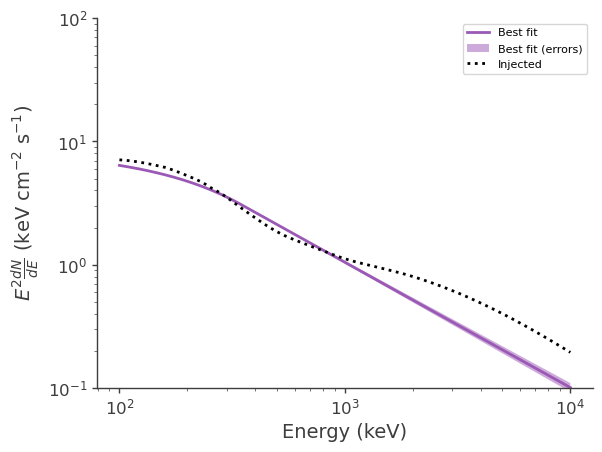

In [56]:
fig,ax = plt.subplots()

ax.plot(energy, energy*energy*flux_median, label = "Best fit")
ax.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
ax.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.set_ylim(.1,100)

_ = ax.legend()

1.16 Plot the fitted spectrum convolved with the response, as well as the simulated source counts

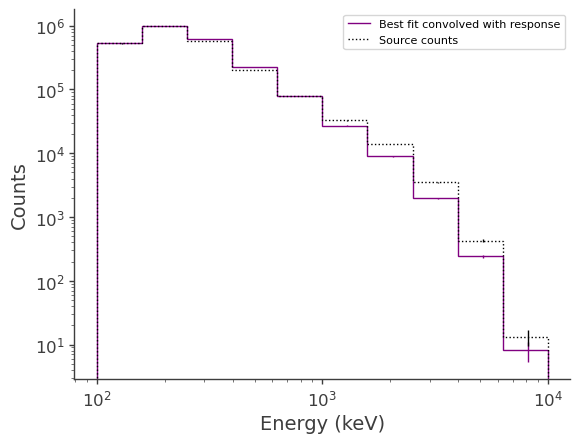

In [57]:
fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(cygX1.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, cygX1.binned_data.project('Em').todense().contents, yerr=np.sqrt(cygX1.binned_data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

_ = ax.legend()

1.17 Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts.

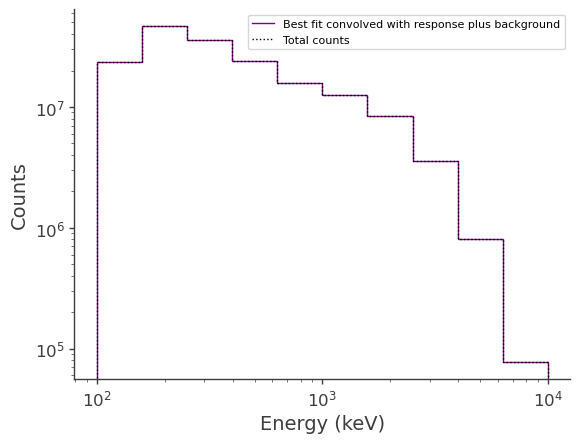

In [58]:
expectation_bkg = bkg.expectation(copy = True)

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents + expectation_bkg.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response plus background")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents+expectation_bkg.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(data.data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Total counts")
ax.errorbar(binned_energy, data.data.project('Em').todense().contents, yerr=np.sqrt(data.data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()